# ECE 533 Final Project

## Deep Learning-Based Lunar Crater Detection Using Object Detection Architectures

### Project Setup and Dataset Initialization

This notebook implements a complete deep learning pipeline for automated lunar crater detection using modern object detection architectures. The workflow was developed in Google Colab and includes dataset preparation, dataset verification, model training, prediction visualization, quantitative evaluation, and comparative performance analysis.

The notebook initializes the project workspace, mounts Google Drive for persistent storage, installs the required dependencies, downloads the crater detection dataset from KaggleHub, and organizes the project directory structure used throughout the experiments.

### Objectives

* Configure the Google Colab development environment
* Mount Google Drive for persistent storage and logging
* Install required Python and deep learning packages
* Download and organize the lunar crater detection dataset
* Verify dataset integrity and annotation formatting
* Visualize ground truth crater bounding boxes
* Train YOLOv8, Faster R-CNN, and RetinaNet crater detectors
* Generate prediction visualizations for all trained models
* Compare detection accuracy and computational performance
* Analyze training time, inference speed, and localization behavior
* Save evaluation metrics, plots, prediction outputs, and comparison summaries

### Project Structure

```text
ece-533-final-project/
├── main.ipynb
├── data/
│   └── martianlunar-crater-detection-dataset/
├── weights/
│   ├── yolo/
│   └── torchvision/
├── logs/
├── dataset_outputs/
│   ├── ground_truth/
│   └── plots/
└── comparison_outputs/
    ├── yolo/
    ├── faster_rcnn/
    ├── retinanet/
    └── plots/
```

### Dataset

Dataset source:
https://www.kaggle.com/datasets/lincolnzh/martianlunar-crater-detection-dataset

The dataset contains annotated lunar and Martian surface imagery formatted for YOLO-based object detection workflows. Images are divided into training, validation, and testing splits and include crater bounding box annotations for supervised object detection tasks.

### Implemented Detection Architectures

The following deep learning object detection architectures were implemented and evaluated throughout this project:

* YOLOv8 Nano
* Faster R-CNN
* RetinaNet

These models were compared using:

* prediction visualization
* crater localization quality
* mAP-based accuracy metrics
* training duration
* inference speed
* computational efficiency

### Experimental Workflow

The notebook is organized into the following major sections:

1. Project Setup and Dataset Initialization
2. Dataset Summary and Inspection
3. Ground Truth Bounding Box Visualization
4. YOLOv8 Training Configuration and Model Training
5. Faster R-CNN and RetinaNet Training
6. Model Evaluation and Comparative Analysis
7. Prediction Bounding Box Visualization
8. Results
9. Discussion
10. Conclusion

The overall goal of this project is to investigate the effectiveness of modern deep learning object detection architectures for automated planetary crater detection and comparative aerospace vision analysis.


# 1. Project Setup and Dataset Initialization

## Overview

This section initializes the crater detection project environment in Google Colab. Required dependencies are installed, Google Drive is mounted for persistent storage, the project directory structure is created, and the lunar crater detection dataset is downloaded from KaggleHub into the local project workspace for later training and evaluation.

## Objectives

* Install required project dependencies
* Mount Google Drive for persistent storage
* Create the project directory structure
* Download and organize the crater detection dataset
* Create output folders if they do not already exist
* Prepare the notebook environment for model training and evaluation



In [2]:
# -------------------------------------------------------
# Install Required Packages
# -------------------------------------------------------

!pip install -q kagglehub ultralytics
!pip install -q torchmetrics

# -------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

# -------------------------------------------------------
# Standard Library Imports
# -------------------------------------------------------

import os
import time
import shutil

from pathlib import Path

# -------------------------------------------------------
# External Libraries
# -------------------------------------------------------

import kagglehub
import pandas as pd

# -------------------------------------------------------
# Project Directory Configuration
# -------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ece-533-final-project"
)

DATA_DIR = PROJECT_DIR / "data"

WEIGHTS_DIR = PROJECT_DIR / "weights"

YOLO_WEIGHTS_DIR = WEIGHTS_DIR / "yolo"

TORCHVISION_WEIGHTS_DIR = (
    WEIGHTS_DIR / "torchvision"
)

LOGS_DIR = PROJECT_DIR / "logs"

DATASET_OUTPUTS_DIR = (
    PROJECT_DIR / "dataset_outputs"
)

GROUND_TRUTH_DIR = (
    DATASET_OUTPUTS_DIR / "ground_truth"
)

DATASET_PLOTS_DIR = (
    DATASET_OUTPUTS_DIR / "plots"
)

COMPARISON_OUTPUTS_DIR = (
    PROJECT_DIR / "comparison_outputs"
)

YOLO_COMPARISON_DIR = (
    COMPARISON_OUTPUTS_DIR / "yolo"
)

FASTER_RCNN_COMPARISON_DIR = (
    COMPARISON_OUTPUTS_DIR / "faster_rcnn"
)

RETINANET_COMPARISON_DIR = (
    COMPARISON_OUTPUTS_DIR / "retinanet"
)

COMPARISON_PLOTS_DIR = (
    COMPARISON_OUTPUTS_DIR / "plots"
)

# -------------------------------------------------------
# Create Project Folders
# -------------------------------------------------------

PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

YOLO_WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TORCHVISION_WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DATASET_OUTPUTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GROUND_TRUTH_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DATASET_PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_OUTPUTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

YOLO_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FASTER_RCNN_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RETINANET_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# -------------------------------------------------------
# Move Runtime Into Project Directory
# -------------------------------------------------------

os.chdir(PROJECT_DIR)

# -------------------------------------------------------
# Download Dataset From KaggleHub
# -------------------------------------------------------

download_path = Path(
    kagglehub.dataset_download(
        "lincolnzh/martianlunar-crater-detection-dataset"
    )
)

print("Downloaded dataset cache:", download_path)

# -------------------------------------------------------
# Copy Dataset Into Project Folder
# -------------------------------------------------------

TARGET_DATASET_DIR = (
    DATA_DIR /
    "martianlunar-crater-detection-dataset"
)

if not TARGET_DATASET_DIR.exists():

    shutil.copytree(
        download_path,
        TARGET_DATASET_DIR,
    )

    print(
        "Dataset copied to:",
        TARGET_DATASET_DIR,
    )

else:

    print(
        "Dataset already exists:",
        TARGET_DATASET_DIR,
    )

# -------------------------------------------------------
# Dataset Path Used By Training Scripts
# -------------------------------------------------------

DATASET_DIR = (
    TARGET_DATASET_DIR /
    "craters"
)

# -------------------------------------------------------
# Environment Summary
# -------------------------------------------------------

print("\n========================================")
print("Project Setup Complete")
print("========================================")

print(f"Project Directory: {PROJECT_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Dataset Directory: {DATASET_DIR}")

print(f"Weights Directory: {WEIGHTS_DIR}")
print(f"YOLO Weights Directory: {YOLO_WEIGHTS_DIR}")

print(
    f"TorchVision Weights Directory: "
    f"{TORCHVISION_WEIGHTS_DIR}"
)

print(f"Logs Directory: {LOGS_DIR}")

print(
    f"Dataset Outputs Directory: "
    f"{DATASET_OUTPUTS_DIR}"
)

print(f"Ground Truth Directory: {GROUND_TRUTH_DIR}")
print(f"Dataset Plots Directory: {DATASET_PLOTS_DIR}")

print(
    f"Comparison Outputs Directory: "
    f"{COMPARISON_OUTPUTS_DIR}"
)

print(
    f"YOLO Comparison Directory: "
    f"{YOLO_COMPARISON_DIR}"
)

print(
    f"Faster R-CNN Comparison Directory: "
    f"{FASTER_RCNN_COMPARISON_DIR}"
)

print(
    f"RetinaNet Comparison Directory: "
    f"{RETINANET_COMPARISON_DIR}"
)

print(
    f"Comparison Plots Directory: "
    f"{COMPARISON_PLOTS_DIR}"
)

print("========================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloaded dataset cache: /root/.cache/kagglehub/datasets/lincolnzh/martianlunar-crater-detection-dataset/versions/2
Dataset already exists: /content/drive/MyDrive/ece-533-final-project/data/martianlunar-crater-detection-dataset

Project Setup Complete
Project Directory: /content/drive/MyDrive/ece-533-final-project
Data Directory: /content/drive/MyDrive/ece-533-final-project/data
Dataset Directory: /content/drive/MyDrive/ece-533-final-project/data/martianlunar-crater-detection-dataset/craters
Weights Directory: /content/drive/MyDrive/ece-533-final-project/weights
YOLO Weights Directory: /content/drive/MyDrive/ece-533-final-project/weights/yolo
TorchVision Weights Directory: /content/drive/MyDrive/ece-533-final-project/weights/torchvision
Logs Directory: /content/drive/MyDrive/ece-533-final-project/logs
Dataset Outputs Directory: /content/drive/MyDrive/ece-533

## 2. Dataset Summary and Inspection

This section verifies the integrity and structure of the crater detection dataset before model training. The dataset is analyzed to confirm that all images and annotation files were downloaded correctly and organized into the expected training, validation, and testing splits.

The script performs the following tasks:

### 2.1 Dataset Split Analysis

* Count the number of images in:

  * training set
  * validation set
  * test set

### 2.2 Annotation Verification

* Count the total number of annotation files
* Count the total number of crater bounding boxes
* Identify empty label files with no crater annotations

### 2.3 Dataset Summary Generation

* Generate a dataset summary table
* Save the summary as a CSV file for later analysis
* Print the dataset statistics to the notebook console

### 2.4 Dataset Visualization

* Generate plots showing:

  * image distribution by dataset split
  * crater annotation distribution
* Display plots directly in the notebook
* Save plots to the dataset output directory

This section ensures the dataset is correctly formatted and provides an overview of the data distribution prior to training the crater detection models.



Dataset Summary and Inspection

Dataset Summary:

   split  num_images  num_label_files  num_crater_boxes  num_empty_labels
0  train          98               98               681                 9
1  valid          26               26               202                 2
2   test          19               19               151                 0

Saved dataset summary CSV:
/content/drive/MyDrive/ece-533-final-project/logs/dataset_summary.csv


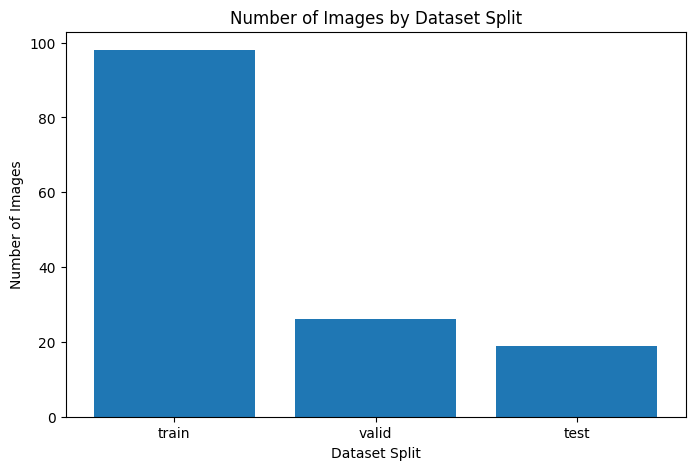


Saved image distribution plot:
/content/drive/MyDrive/ece-533-final-project/dataset_outputs/plots/dataset_image_distribution.png


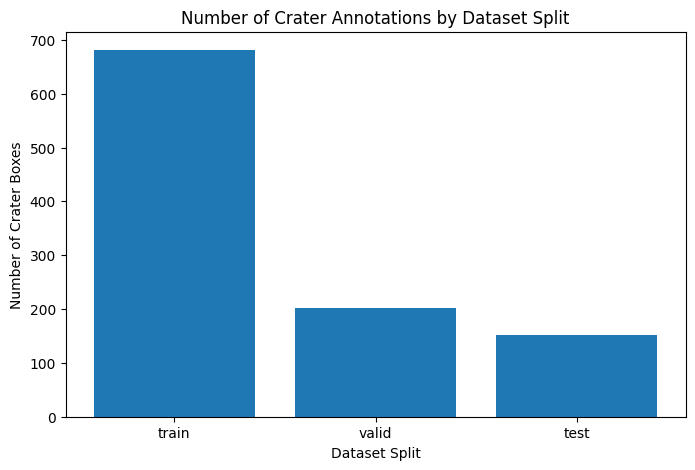


Saved annotation distribution plot:
/content/drive/MyDrive/ece-533-final-project/dataset_outputs/plots/dataset_annotation_distribution.png

Saved dataset summary text file:
/content/drive/MyDrive/ece-533-final-project/logs/dataset_summary.txt

Dataset Inspection Complete
CSV Summary: /content/drive/MyDrive/ece-533-final-project/logs/dataset_summary.csv
Text Summary: /content/drive/MyDrive/ece-533-final-project/logs/dataset_summary.txt
Plots saved to: /content/drive/MyDrive/ece-533-final-project/dataset_outputs/plots


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# -------------------------------------------------------
# Dataset Summary and Inspection
# -------------------------------------------------------

print("\n========================================")
print("Dataset Summary and Inspection")
print("========================================")

splits = [
    "train",
    "valid",
    "test",
]

summary_rows = []

for split in splits:

    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    images = list(image_dir.glob("*.jpg"))

    labels = list(label_dir.glob("*.txt"))

    crater_boxes = 0
    empty_labels = 0

    for label_path in labels:

        lines = (
            label_path
            .read_text()
            .strip()
            .splitlines()
        )

        if len(lines) == 0:
            empty_labels += 1

        crater_boxes += len(lines)

    summary_rows.append(
        {
            "split": split,
            "num_images": len(images),
            "num_label_files": len(labels),
            "num_crater_boxes": crater_boxes,
            "num_empty_labels": empty_labels,
        }
    )

# -------------------------------------------------------
# Create Summary DataFrame
# -------------------------------------------------------

summary_df = pd.DataFrame(summary_rows)

print("\nDataset Summary:\n")
print(summary_df)

# -------------------------------------------------------
# Save Dataset Summary CSV
# -------------------------------------------------------

summary_csv_path = (
    LOGS_DIR /
    "dataset_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False,
)

print(f"\nSaved dataset summary CSV:")
print(summary_csv_path)

# -------------------------------------------------------
# Plot Image Counts
# -------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["split"],
    summary_df["num_images"],
)

plt.title("Number of Images by Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

image_plot_path = (
    DATASET_PLOTS_DIR /
    "dataset_image_distribution.png"
)

plt.savefig(
    image_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nSaved image distribution plot:")
print(image_plot_path)

# -------------------------------------------------------
# Plot Crater Annotation Counts
# -------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["split"],
    summary_df["num_crater_boxes"],
)

plt.title("Number of Crater Annotations by Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Crater Boxes")

annotation_plot_path = (
    DATASET_PLOTS_DIR /
    "dataset_annotation_distribution.png"
)

plt.savefig(
    annotation_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nSaved annotation distribution plot:")
print(annotation_plot_path)

# -------------------------------------------------------
# Save Dataset Summary Text File
# -------------------------------------------------------

summary_txt_path = (
    LOGS_DIR /
    "dataset_summary.txt"
)

with open(summary_txt_path, "w") as f:

    f.write(
        "Dataset Summary and Inspection\n"
    )

    f.write(
        "========================================\n\n"
    )

    f.write(summary_df.to_string(index=False))

print(f"\nSaved dataset summary text file:")
print(summary_txt_path)

# -------------------------------------------------------
# Final Summary
# -------------------------------------------------------

print("\n========================================")
print("Dataset Inspection Complete")
print("========================================")

print(f"CSV Summary: {summary_csv_path}")

print(f"Text Summary: {summary_txt_path}")

print(
    f"Plots saved to: "
    f"{DATASET_PLOTS_DIR}"
)

print("========================================")

In [3]:
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

# -------------------------------------------------------
# Ground Truth Bounding Box Visualization
# -------------------------------------------------------

print("\n========================================")
print("Ground Truth Bounding Box Visualization")
print("========================================")

split = "test"

image_dir = DATASET_DIR / split / "images"
label_dir = DATASET_DIR / split / "labels"

image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.png"))
)

if len(image_paths) == 0:
    raise FileNotFoundError(
        f"No images found in: {image_dir}"
    )

print(f"Found {len(image_paths)} {split} images.")

# -------------------------------------------------------
# Draw and Save Ground Truth Images
# -------------------------------------------------------

ground_truth_rows = []

for image_path in image_paths:

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Skipping unreadable image: {image_path}")
        continue

    h, w = image.shape[:2]

    label_path = label_dir / f"{image_path.stem}.txt"

    num_boxes = 0

    if label_path.exists() and label_path.read_text().strip():

        lines = (
            label_path
            .read_text()
            .strip()
            .splitlines()
        )

        for line in lines:

            cls, xc, yc, bw, bh = map(
                float,
                line.split()
            )

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
            )

            cv2.putText(
                image,
                "crater",
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
            )

            num_boxes += 1

    output_path = GROUND_TRUTH_DIR / image_path.name

    cv2.imwrite(
        str(output_path),
        image,
    )

    ground_truth_rows.append(
        {
            "image": image_path.name,
            "split": split,
            "num_ground_truth_boxes": num_boxes,
            "label_path": str(label_path),
            "output_path": str(output_path),
        }
    )

# -------------------------------------------------------
# Save Ground Truth Summary CSV
# -------------------------------------------------------

ground_truth_df = pd.DataFrame(
    ground_truth_rows
)

ground_truth_csv_path = (
    LOGS_DIR /
    "ground_truth_visualization_summary.csv"
)

ground_truth_df.to_csv(
    ground_truth_csv_path,
    index=False,
)

print("\nGround Truth Visualization Summary:")
print(ground_truth_df.head())

print(f"\nSaved ground truth summary CSV:")
print(ground_truth_csv_path)

print(f"\nSaved annotated ground truth images to:")
print(GROUND_TRUTH_DIR)

# -------------------------------------------------------
# Display a Few Ground Truth Examples
# -------------------------------------------------------

num_examples_to_show = 5

example_paths = list(
    ground_truth_df["output_path"]
)[:num_examples_to_show]

for example_path in example_paths:

    image = cv2.imread(example_path)

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    plt.figure(figsize=(7, 7))

    plt.imshow(image_rgb)

    plt.axis("off")

    plt.title(
        Path(example_path).name
    )

    plt.show()

# -------------------------------------------------------
# Final Summary
# -------------------------------------------------------

print("\n========================================")
print("Ground Truth Visualization Complete")
print("========================================")

print(f"Images processed: {len(ground_truth_df)}")
print(f"Total ground truth boxes: {ground_truth_df['num_ground_truth_boxes'].sum()}")
print(f"CSV Summary: {ground_truth_csv_path}")
print(f"Ground Truth Image Directory: {GROUND_TRUTH_DIR}")

print("========================================")

Output hidden; open in https://colab.research.google.com to view.

# 3. YOLOv8 Training Configuration and Model Training

## Overview

This section configures the YOLOv8 training pipeline for lunar crater detection. The dataset configuration file (`data.yaml`) defines the dataset structure, image paths, and object classes used during training. After the dataset configuration is created, the YOLOv8 nano model (`yolov8n.pt`) is initialized and trained on the crater dataset.

## Objectives

* Define the dataset structure for YOLOv8
* Configure training and validation image paths
* Specify crater detection as the target object class
* Initialize a pretrained YOLOv8 model
* Train the detector on lunar surface imagery
* Save trained weights to Google Drive

## 3.1 Create YOLO Dataset Configuration File

This code cell creates the `data.yaml` configuration file used by YOLOv8 during training. The file defines the dataset root directory, training and validation image paths, test data location, and the crater object class label.

In [41]:
%%writefile "/content/drive/MyDrive/ece-533-final-project/data.yaml"
path: /content/drive/MyDrive/ece-533-final-project/data/martianlunar-crater-detection-dataset/craters

train: train/images
val: valid/images
test: test/images

names:
  0: crater

Overwriting /content/drive/MyDrive/ece-533-final-project/data.yaml


## 3.2 Train the YOLOv8 Crater Detection Model

This code cell initializes a pretrained YOLOv8 nano model and trains it on the lunar crater dataset. Training parameters such as image size, batch size, and number of epochs are configured, and the trained model weights are saved to Google Drive for later evaluation and inference.


In [42]:
import time
import pandas as pd

from pathlib import Path
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

training_start = time.time()

results = model.train(
    data="/content/drive/MyDrive/ece-533-final-project/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    project="/content/drive/MyDrive/ece-533-final-project/weights/yolo",
    name="yolo_crater_detector",
)

total_training_time = time.time() - training_start

results_csv = Path(
    "/content/drive/MyDrive/ece-533-final-project/weights/yolo/yolo_crater_detector/results.csv"
)

log_output_path = Path(
    "/content/drive/MyDrive/ece-533-final-project/logs/yolo_training_log.csv"
)

summary_path = Path(
    "/content/drive/MyDrive/ece-533-final-project/logs/yolo_training_summary.txt"
)

training_df = pd.read_csv(results_csv)

training_df["model"] = "yolov8n"
training_df["total_training_time_sec"] = total_training_time
training_df["avg_epoch_time_sec"] = total_training_time / len(training_df)
training_df["batch_size"] = 8
training_df["epochs"] = 50
training_df["image_size"] = 640

training_df.to_csv(
    log_output_path,
    index=False,
)

with open(summary_path, "w") as f:
    f.write("YOLOv8 Crater Detection Training Summary\n")
    f.write("========================================\n")
    f.write("Model: yolov8n\n")
    f.write("Epochs: 50\n")
    f.write("Batch Size: 8\n")
    f.write("Image Size: 640\n")
    f.write(f"Total Training Time Sec: {total_training_time:.2f}\n")
    f.write(f"Average Epoch Time Sec: {total_training_time / len(training_df):.2f}\n")

print("\nYOLOv8 training complete")
print(f"Total training time: {total_training_time:.2f} sec")
print(f"Average epoch time: {total_training_time / len(training_df):.2f} sec")
print(f"Training log saved to: {log_output_path}")
print(f"Summary saved to: {summary_path}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ece-533-final-project/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_crater_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

# 4. Faster R-CNN and RetinaNet Training

## Overview

This section trains two TorchVision object detection models, Faster R-CNN and RetinaNet, on the crater detection dataset. The dataset labels are currently in YOLO format, so the custom dataset class converts each annotation into bounding box coordinates that PyTorch detection models can use.

## Objectives

* Load crater images and YOLO label files
* Convert YOLO annotations into PyTorch bounding boxes
* Initialize Faster R-CNN and RetinaNet models
* Train both models for 50 epochs
* Use a T4-friendly batch size of 4
* Save checkpoints and final model weights


In [43]:
from pathlib import Path
import time
import shutil
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from tqdm import tqdm

from torchvision.transforms import functional as F

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    retinanet_resnet50_fpn,
)

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead


PROJECT_DIR = Path("/content/drive/MyDrive/ece-533-final-project")

DRIVE_DATASET_DIR = (
    PROJECT_DIR /
    "data" /
    "martianlunar-crater-detection-dataset" /
    "craters"
)

LOCAL_DATASET_DIR = Path("/content/craters")

WEIGHTS_DIR = PROJECT_DIR / "weights" / "torchvision"
LOGS_DIR = PROJECT_DIR / "logs"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# -------------------------------------------------------
# Copy Dataset to Local Colab Storage for Faster Training
# -------------------------------------------------------

if not LOCAL_DATASET_DIR.exists():
    shutil.copytree(
        DRIVE_DATASET_DIR,
        LOCAL_DATASET_DIR,
    )
    print("Dataset copied to local Colab storage.")
else:
    print("Local dataset already exists.")

DATASET_DIR = LOCAL_DATASET_DIR

print(f"Using dataset: {DATASET_DIR}")


class CraterDataset(Dataset):
    def __init__(self, split):
        self.image_dir = DATASET_DIR / split / "images"
        self.label_dir = DATASET_DIR / split / "labels"

        self.images = sorted(self.image_dir.glob("*.jpg"))

        if len(self.images) == 0:
            raise FileNotFoundError(
                f"No images found in: {self.image_dir}"
            )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = Image.open(image_path).convert("RGB")

        w, h = image.size
        label_path = self.label_dir / f"{image_path.stem}.txt"

        boxes = []
        labels = []

        if label_path.exists() and label_path.read_text().strip():
            lines = label_path.read_text().strip().splitlines()

            for line in lines:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                x2 = (xc + bw / 2) * w
                y2 = (yc + bh / 2) * h

                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        image = F.to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


def get_faster_rcnn():
    print("\nLoading Faster R-CNN model...")

    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    num_classes = 2

    in_features = (
        model.roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    print("Faster R-CNN loaded successfully")

    return model


def get_retinanet():
    print("\nLoading RetinaNet model...")

    model = retinanet_resnet50_fpn(weights="DEFAULT")

    num_classes = 2

    num_anchors = (
        model.head
        .classification_head
        .num_anchors
    )

    in_channels = (
        model.head
        .classification_head
        .conv[0]
        .out_channels
    )

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )

    print("RetinaNet loaded successfully")

    return model


def train_model(
    model,
    model_name,
    epochs=50,
    batch_size=4,
    lr=1e-4,
):
    model.to(DEVICE)

    train_ds = CraterDataset("train")

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
    )

    log_rows = []
    best_loss = float("inf")

    best_path = WEIGHTS_DIR / f"{model_name}_best.pth"
    last_path = WEIGHTS_DIR / f"{model_name}_last.pth"
    log_path = LOGS_DIR / f"{model_name}_training_log.csv"
    summary_path = LOGS_DIR / f"{model_name}_summary.txt"

    total_training_start = time.time()

    print("\n========================================")
    print(f"Starting training for {model_name}")
    print("========================================")
    print(f"Dataset path: {DATASET_DIR}")
    print(f"Training images: {len(train_ds)}")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Device: {DEVICE}")
    print(f"Weights dir: {WEIGHTS_DIR}")
    print(f"Logs dir: {LOGS_DIR}")
    print("========================================\n")

    model.train()

    for epoch in range(epochs):
        epoch_start = time.time()
        total_loss = 0.0
        batch_times = []

        print(f"\n----- Epoch {epoch + 1}/{epochs} -----")

        progress_bar = tqdm(
            train_loader,
            desc=model_name,
            unit="batch",
        )

        for images, targets in progress_bar:
            batch_start = time.time()

            images = [
                img.to(DEVICE)
                for img in images
            ]

            targets = [
                {
                    k: v.to(DEVICE)
                    for k, v in t.items()
                }
                for t in targets
            ]

            loss_dict = model(images, targets)

            loss = sum(
                loss_value
                for loss_value in loss_dict.values()
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()

            batch_time = time.time() - batch_start
            batch_times.append(batch_time)

            total_loss += loss.item()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                batch_time=f"{batch_time:.2f}s",
            )

        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(train_loader)
        avg_batch_time = sum(batch_times) / len(batch_times)

        saved_best = False

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), best_path)
            saved_best = True

        log_rows.append(
            {
                "model": model_name,
                "epoch": epoch + 1,
                "avg_loss": avg_loss,
                "best_loss": best_loss,
                "epoch_time_sec": epoch_time,
                "avg_batch_time_sec": avg_batch_time,
                "num_batches": len(train_loader),
                "batch_size": batch_size,
                "learning_rate": lr,
                "saved_best": saved_best,
                "best_model_path": str(best_path),
                "last_model_path": str(last_path),
            }
        )

        pd.DataFrame(log_rows).to_csv(
            log_path,
            index=False,
        )

        print(f"Average loss: {avg_loss:.4f}")
        print(f"Best loss: {best_loss:.4f}")
        print(f"Epoch time: {epoch_time:.2f} sec")
        print(f"Average batch time: {avg_batch_time:.2f} sec")

        if saved_best:
            print(f"Saved new best model: {best_path}")

        print(f"Updated log: {log_path}")

    total_training_time = time.time() - total_training_start

    torch.save(model.state_dict(), last_path)

    with open(summary_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Epochs: {epochs}\n")
        f.write(f"Batch size: {batch_size}\n")
        f.write(f"Learning rate: {lr}\n")
        f.write(f"Device: {DEVICE}\n")
        f.write(f"Best loss: {best_loss:.6f}\n")
        f.write(f"Total training time sec: {total_training_time:.2f}\n")
        f.write(f"Average epoch time sec: {total_training_time / epochs:.2f}\n")
        f.write(f"Best model path: {best_path}\n")
        f.write(f"Last model path: {last_path}\n")

    print(f"\nFinished training {model_name}")
    print(f"Total training time: {total_training_time:.2f} sec")
    print(f"Saved best model: {best_path}")
    print(f"Saved last model: {last_path}")
    print(f"Saved training log: {log_path}")
    print(f"Saved summary: {summary_path}")


print("\n========================================")
print("TorchVision Crater Detection Training")
print("========================================")
print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("========================================")


faster_rcnn = get_faster_rcnn()

train_model(
    faster_rcnn,
    "faster_rcnn_crater",
    epochs=50,
    batch_size=4,
    lr=1e-4,
)


retinanet = get_retinanet()

train_model(
    retinanet,
    "retinanet_crater",
    epochs=50,
    batch_size=4,
    lr=1e-4,
)

Local dataset already exists.
Using dataset: /content/craters

TorchVision Crater Detection Training
Using device: cuda
GPU: Tesla T4

Loading Faster R-CNN model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Faster R-CNN loaded successfully

Starting training for faster_rcnn_crater
Dataset path: /content/craters
Training images: 98
Batch size: 4
Epochs: 50
Learning rate: 0.0001
Device: cuda
Weights dir: /content/drive/MyDrive/ece-533-final-project/weights/torchvision
Logs dir: /content/drive/MyDrive/ece-533-final-project/logs


----- Epoch 1/50 -----


faster_rcnn_crater:   0%|          | 0/25 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
faster_rcnn_crater: 100%|██████████| 25/25 [00:23<00:00,  1.06batch/s, batch_time=0.48s, loss=0.6569]


Average loss: 0.6953
Best loss: 0.6953
Epoch time: 23.70 sec
Average batch time: 0.92 sec
Saved new best model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/faster_rcnn_crater_best.pth
Updated log: /content/drive/MyDrive/ece-533-final-project/logs/faster_rcnn_crater_training_log.csv

----- Epoch 2/50 -----


...

Average loss: 0.0937
Best loss: 0.0937
Epoch time: 20.33 sec
Average batch time: 0.79 sec
Saved new best model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/retinanet_crater_best.pth
Updated log: /content/drive/MyDrive/ece-533-final-project/logs/retinanet_crater_training_log.csv

----- Epoch 49/50 -----


retinanet_crater: 100%|██████████| 25/25 [00:20<00:00,  1.24batch/s, batch_time=0.42s, loss=0.1068]


Average loss: 0.0918
Best loss: 0.0918
Epoch time: 20.15 sec
Average batch time: 0.79 sec
Saved new best model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/retinanet_crater_best.pth
Updated log: /content/drive/MyDrive/ece-533-final-project/logs/retinanet_crater_training_log.csv

----- Epoch 50/50 -----


retinanet_crater: 100%|██████████| 25/25 [00:20<00:00,  1.24batch/s, batch_time=0.42s, loss=0.0884]


Average loss: 0.0866
Best loss: 0.0866
Epoch time: 20.11 sec
Average batch time: 0.79 sec
Saved new best model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/retinanet_crater_best.pth
Updated log: /content/drive/MyDrive/ece-533-final-project/logs/retinanet_crater_training_log.csv

Finished training retinanet_crater
Total training time: 1023.79 sec
Saved best model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/retinanet_crater_best.pth
Saved last model: /content/drive/MyDrive/ece-533-final-project/weights/torchvision/retinanet_crater_last.pth
Saved training log: /content/drive/MyDrive/ece-533-final-project/logs/retinanet_crater_training_log.csv
Saved summary: /content/drive/MyDrive/ece-533-final-project/logs/retinanet_crater_summary.txt


## 5. Model Evaluation and Comparative Analysis

This section evaluates the trained crater detection models using the full test dataset. The evaluation compares YOLOv8, Faster R-CNN, and RetinaNet across both qualitative and quantitative metrics.

The script performs the following tasks:

### 5.1 Load Trained Models

* Load the trained YOLOv8 model
* Load the trained Faster R-CNN model
* Load the trained RetinaNet model

### 5.2 Run Inference on the Full Test Dataset

* Process all images in the test dataset
* Perform crater detection using each model
* Apply confidence threshold filtering to predicted detections

### 5.3 Save Visual Prediction Outputs

* Draw predicted crater bounding boxes
* Overlay prediction confidence scores
* Save prediction images for each model into separate output directories

### 5.4 Measure Computational Performance

* Measure total inference time
* Measure average inference time per image
* Estimate inference throughput (FPS)

### 5.5 Compare Detection Statistics

* Count detections per image
* Compute average detections across the dataset
* Compare detection behavior between models

### 5.6 Load and Compare Training Metrics

* Load previously saved training logs
* Compare:

  * Total training time
  * Average epoch time
  * Final training loss
  * Best training loss

### 5.7 Generate Comparative Plots

The script generates and saves plots for:

* Total training time
* Total inference time
* Average inference time per image
* Average detections per image

### 5.8 Save Final Evaluation Results

The evaluation script saves:

* Prediction images
* Inference logs
* Comparison summary CSV files
* Comparison summary text files
* Visualization plots

All outputs are stored in the project comparison output directories for later analysis and reporting.



Crater Detector Comparison
Using device: cuda
GPU: Tesla T4
Number of test images: 19

Loading models...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.9MB/s]


YOLO weights: /content/drive/MyDrive/ece-533-final-project/weights/yolo/yolo_crater_detector/weights/best.pt
Models loaded successfully.

Running YOLO inference...

Running Faster R-CNN inference...

Running RetinaNet inference...

Saved inference log: /content/drive/MyDrive/ece-533-final-project/logs/inference_comparison_log.csv
Saved comparison summary: /content/drive/MyDrive/ece-533-final-project/logs/model_comparison_summary.csv


,model,training_log_found,training_total_time_sec,training_avg_epoch_time_sec,training_final_loss,training_best_loss,num_test_images,total_detections,avg_detections_per_image,inference_total_time_sec,inference_avg_time_per_image_sec,inference_fps
0,faster_rcnn_crater,True,1098.359428,21.967189,0.081283,0.063145,19,135,7.105263,1.592319,0.083806,11.932279
1,retinanet_crater,True,1008.029006,20.160580,0.086646,0.086646,19,127,6.684211,1.437856,0.075677,13.214115
2,yolov8n,True,182.787466,3.655749,1.305340,1.200210,19,125,6.578947,0.804036,0.042318,23.630779


Saved text summary: /content/drive/MyDrive/ece-533-final-project/logs/model_comparison_summary.txt


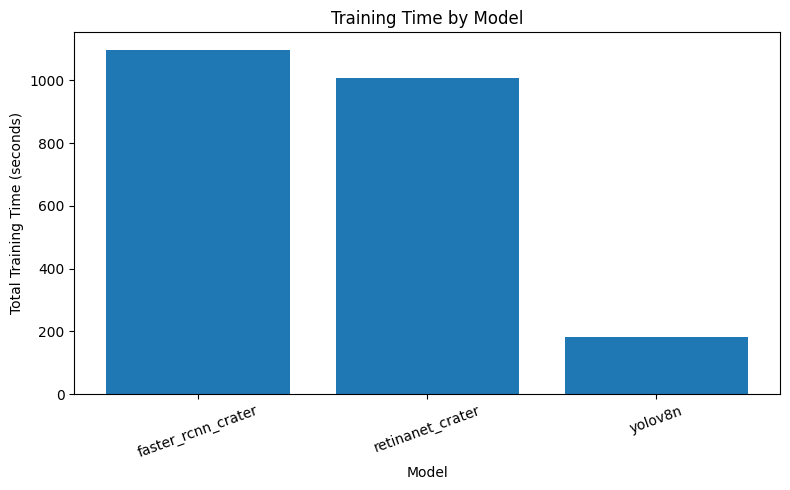

Saved plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/training_time_comparison.png


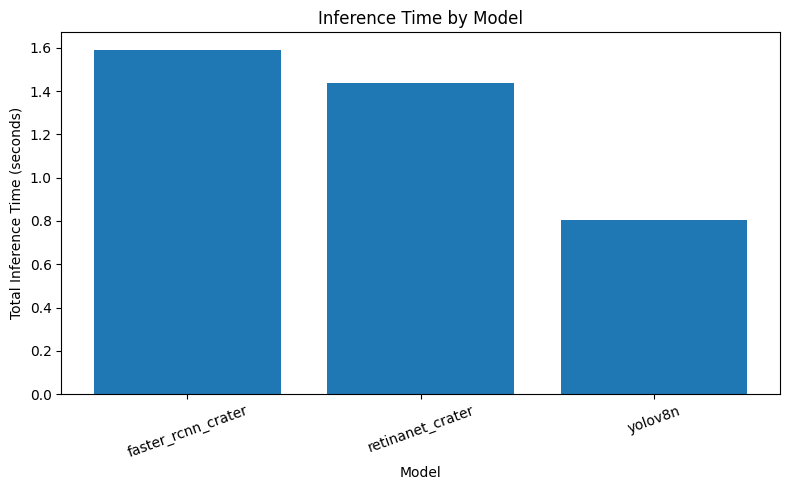

Saved plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/inference_time_comparison.png


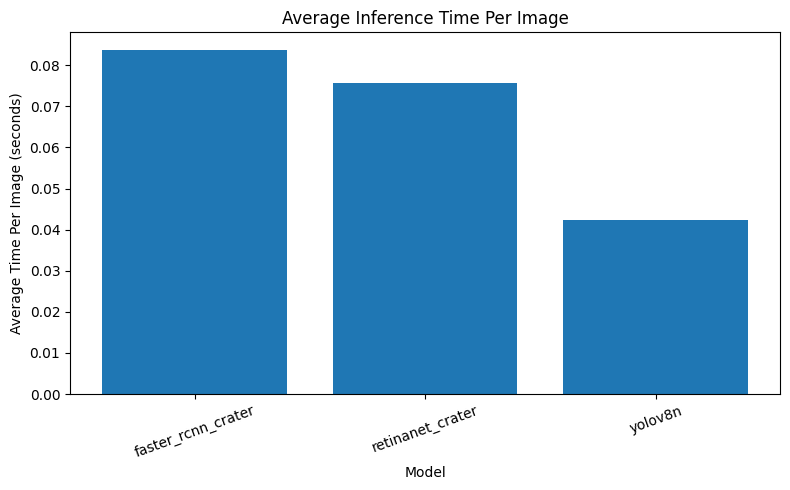

Saved plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/avg_inference_time_per_image.png


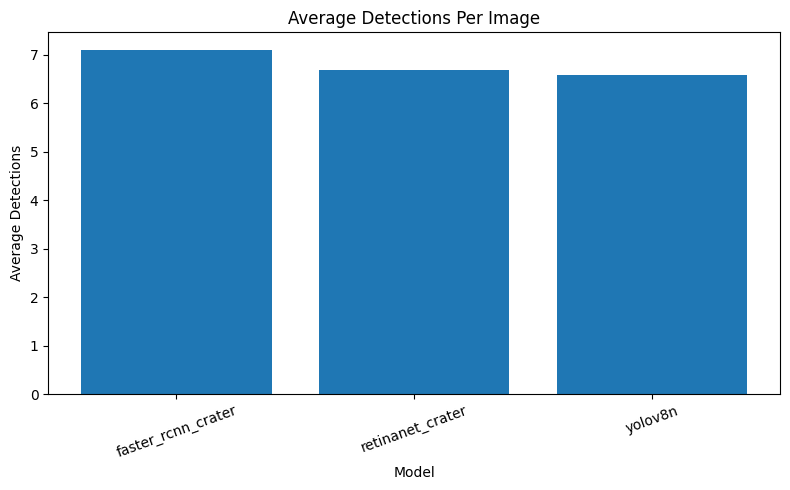

Saved plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/avg_detections_per_image.png

Comparison Complete
Visual outputs saved to: /content/drive/MyDrive/ece-533-final-project/comparison_outputs
Plots saved to: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots
Logs saved to: /content/drive/MyDrive/ece-533-final-project/logs


In [46]:
from pathlib import Path
import time
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image

from torchvision.transforms import functional as F
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    retinanet_resnet50_fpn,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

from ultralytics import YOLO


# -------------------------------------------------------
# Paths
# -------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/ece-533-final-project")

DATASET_DIR = (
    PROJECT_DIR /
    "data" /
    "martianlunar-crater-detection-dataset" /
    "craters"
)

WEIGHTS_DIR = PROJECT_DIR / "weights"
TORCHVISION_WEIGHTS_DIR = WEIGHTS_DIR / "torchvision"
YOLO_WEIGHTS_DIR = WEIGHTS_DIR / "yolo"

LOGS_DIR = PROJECT_DIR / "logs"

COMPARISON_OUTPUTS_DIR = PROJECT_DIR / "comparison_outputs"
YOLO_COMPARISON_DIR = COMPARISON_OUTPUTS_DIR / "yolo"
FASTER_RCNN_COMPARISON_DIR = COMPARISON_OUTPUTS_DIR / "faster_rcnn"
RETINANET_COMPARISON_DIR = COMPARISON_OUTPUTS_DIR / "retinanet"
PLOTS_DIR = COMPARISON_OUTPUTS_DIR / "plots"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------------------------------------
# Helper: Find Model Weights
# -------------------------------------------------------

def find_yolo_best_weights():
    candidates = list(YOLO_WEIGHTS_DIR.rglob("best.pt"))

    if len(candidates) == 0:
        candidates = list(WEIGHTS_DIR.rglob("best.pt"))

    if len(candidates) == 0:
        raise FileNotFoundError("Could not find YOLO best.pt weights.")

    return candidates[0]


def get_faster_rcnn():
    model = fasterrcnn_resnet50_fpn(weights=None)

    num_classes = 2

    in_features = (
        model.roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    weights_path = TORCHVISION_WEIGHTS_DIR / "faster_rcnn_crater_best.pth"

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model


def get_retinanet():
    model = retinanet_resnet50_fpn(weights=None)

    num_classes = 2

    num_anchors = (
        model.head
        .classification_head
        .num_anchors
    )

    in_channels = (
        model.head
        .classification_head
        .conv[0]
        .out_channels
    )

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )

    weights_path = TORCHVISION_WEIGHTS_DIR / "retinanet_crater_best.pth"

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model


# -------------------------------------------------------
# Helper: Draw TorchVision Predictions
# -------------------------------------------------------

def run_torchvision_model(
    model,
    model_name,
    image_paths,
    output_dir,
    threshold=0.3,
):
    rows = []

    total_start = time.time()

    for image_path in image_paths:
        image_start = time.time()

        image = Image.open(image_path).convert("RGB")
        tensor = F.to_tensor(image).to(DEVICE)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        inference_start = time.time()

        with torch.no_grad():
            prediction = model([tensor])[0]

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        inference_time = time.time() - inference_start

        image_cv = cv2.imread(str(image_path))

        boxes = prediction["boxes"].detach().cpu().numpy()
        scores = prediction["scores"].detach().cpu().numpy()

        detections = 0

        for box, score in zip(boxes, scores):
            if score < threshold:
                continue

            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(
                image_cv,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
            )

            cv2.putText(
                image_cv,
                f"{score:.2f}",
                (x1, max(y1 - 10, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
            )

            detections += 1

        output_path = output_dir / image_path.name

        cv2.imwrite(
            str(output_path),
            image_cv,
        )

        rows.append(
            {
                "model": model_name,
                "image": image_path.name,
                "detections": detections,
                "inference_time_sec": inference_time,
                "total_image_time_sec": time.time() - image_start,
                "output_path": str(output_path),
            }
        )

    total_time = time.time() - total_start

    return rows, total_time


def run_yolo_model(
    model,
    image_paths,
    output_dir,
    threshold=0.3,
):
    rows = []

    total_start = time.time()

    for image_path in image_paths:
        image_start = time.time()

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        inference_start = time.time()

        results = model.predict(
            source=str(image_path),
            conf=threshold,
            save=False,
            verbose=False,
            device=0 if DEVICE.type == "cuda" else "cpu",
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        inference_time = time.time() - inference_start

        image_cv = cv2.imread(str(image_path))

        detections = 0

        for box in results[0].boxes:
            score = float(box.conf[0])

            if score < threshold:
                continue

            x1, y1, x2, y2 = map(
                int,
                box.xyxy[0].detach().cpu().numpy(),
            )

            cv2.rectangle(
                image_cv,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
            )

            cv2.putText(
                image_cv,
                f"{score:.2f}",
                (x1, max(y1 - 10, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
            )

            detections += 1

        output_path = output_dir / image_path.name

        cv2.imwrite(
            str(output_path),
            image_cv,
        )

        rows.append(
            {
                "model": "yolov8n",
                "image": image_path.name,
                "detections": detections,
                "inference_time_sec": inference_time,
                "total_image_time_sec": time.time() - image_start,
                "output_path": str(output_path),
            }
        )

    total_time = time.time() - total_start

    return rows, total_time


# -------------------------------------------------------
# Helper: Training Log Summary
# -------------------------------------------------------

def summarize_training_logs():
    summaries = []

    training_logs = {
        "yolov8n": LOGS_DIR / "yolo_training_log.csv",
        "faster_rcnn_crater": LOGS_DIR / "faster_rcnn_crater_training_log.csv",
        "retinanet_crater": LOGS_DIR / "retinanet_crater_training_log.csv",
    }

    for model_name, log_path in training_logs.items():
        if not log_path.exists():
            summaries.append(
                {
                    "model": model_name,
                    "training_log_found": False,
                    "training_total_time_sec": None,
                    "training_avg_epoch_time_sec": None,
                    "training_final_loss": None,
                    "training_best_loss": None,
                }
            )
            continue

        df = pd.read_csv(log_path)

        total_time = (
            df["total_training_time_sec"].iloc[-1]
            if "total_training_time_sec" in df.columns
            else df["epoch_time_sec"].sum()
            if "epoch_time_sec" in df.columns
            else None
        )

        avg_epoch_time = (
            df["avg_epoch_time_sec"].iloc[-1]
            if "avg_epoch_time_sec" in df.columns
            else df["epoch_time_sec"].mean()
            if "epoch_time_sec" in df.columns
            else None
        )

        loss_cols = [
            col for col in df.columns
            if "loss" in col.lower()
        ]

        final_loss = (
            df[loss_cols[0]].iloc[-1]
            if len(loss_cols) > 0
            else None
        )

        best_loss = (
            df["best_loss"].min()
            if "best_loss" in df.columns
            else df[loss_cols[0]].min()
            if len(loss_cols) > 0
            else None
        )

        summaries.append(
            {
                "model": model_name,
                "training_log_found": True,
                "training_total_time_sec": total_time,
                "training_avg_epoch_time_sec": avg_epoch_time,
                "training_final_loss": final_loss,
                "training_best_loss": best_loss,
            }
        )

    return pd.DataFrame(summaries)


# -------------------------------------------------------
# Helper: Plot Results
# -------------------------------------------------------

def save_and_show_bar_plot(
    df,
    x_col,
    y_col,
    title,
    ylabel,
    filename,
):
    plt.figure(figsize=(8, 5))

    plt.bar(
        df[x_col],
        df[y_col],
    )

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.xticks(rotation=20)
    plt.tight_layout()

    plot_path = PLOTS_DIR / filename

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved plot: {plot_path}")


# -------------------------------------------------------
# Main Comparison
# -------------------------------------------------------

print("\n========================================")
print("Crater Detector Comparison")
print("========================================")
print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("========================================")


test_dir = DATASET_DIR / "test" / "images"

test_images = sorted(
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

if len(test_images) == 0:
    raise FileNotFoundError(
        f"No test images found in: {test_dir}"
    )

print(f"Number of test images: {len(test_images)}")


# -------------------------------------------------------
# Load Models
# -------------------------------------------------------

print("\nLoading models...")

faster_rcnn = get_faster_rcnn()
retinanet = get_retinanet()

yolo_weights = find_yolo_best_weights()
yolo_model = YOLO(str(yolo_weights))

print(f"YOLO weights: {yolo_weights}")
print("Models loaded successfully.")


# -------------------------------------------------------
# Run Inference
# -------------------------------------------------------

all_inference_rows = []

print("\nRunning YOLO inference...")
yolo_rows, yolo_total_time = run_yolo_model(
    yolo_model,
    test_images,
    YOLO_COMPARISON_DIR,
)

all_inference_rows.extend(yolo_rows)


print("\nRunning Faster R-CNN inference...")
faster_rows, faster_total_time = run_torchvision_model(
    faster_rcnn,
    "faster_rcnn_crater",
    test_images,
    FASTER_RCNN_COMPARISON_DIR,
)

all_inference_rows.extend(faster_rows)


print("\nRunning RetinaNet inference...")
retina_rows, retina_total_time = run_torchvision_model(
    retinanet,
    "retinanet_crater",
    test_images,
    RETINANET_COMPARISON_DIR,
)

all_inference_rows.extend(retina_rows)


# -------------------------------------------------------
# Save Inference Logs
# -------------------------------------------------------

inference_df = pd.DataFrame(all_inference_rows)

inference_log_path = LOGS_DIR / "inference_comparison_log.csv"

inference_df.to_csv(
    inference_log_path,
    index=False,
)

print(f"\nSaved inference log: {inference_log_path}")


# -------------------------------------------------------
# Build Summary Table
# -------------------------------------------------------

inference_summary = (
    inference_df
    .groupby("model")
    .agg(
        num_test_images=("image", "count"),
        total_detections=("detections", "sum"),
        avg_detections_per_image=("detections", "mean"),
        inference_total_time_sec=("inference_time_sec", "sum"),
        inference_avg_time_per_image_sec=("inference_time_sec", "mean"),
    )
    .reset_index()
)

inference_summary["inference_fps"] = (
    inference_summary["num_test_images"] /
    inference_summary["inference_total_time_sec"]
)

training_summary = summarize_training_logs()

comparison_summary = pd.merge(
    training_summary,
    inference_summary,
    on="model",
    how="outer",
)

comparison_summary_path = LOGS_DIR / "model_comparison_summary.csv"

comparison_summary.to_csv(
    comparison_summary_path,
    index=False,
)

print(f"Saved comparison summary: {comparison_summary_path}")

display(comparison_summary)


# -------------------------------------------------------
# Save Text Summary
# -------------------------------------------------------

summary_txt_path = LOGS_DIR / "model_comparison_summary.txt"

with open(summary_txt_path, "w") as f:
    f.write("Crater Detector Model Comparison\n")
    f.write("================================\n\n")

    f.write(f"Number of test images: {len(test_images)}\n")
    f.write(f"Device: {DEVICE}\n")

    if DEVICE.type == "cuda":
        f.write(f"GPU: {torch.cuda.get_device_name(0)}\n")

    f.write("\nComparison Summary:\n")
    f.write(comparison_summary.to_string(index=False))

print(f"Saved text summary: {summary_txt_path}")


# -------------------------------------------------------
# Plot Results
# -------------------------------------------------------

save_and_show_bar_plot(
    comparison_summary,
    "model",
    "training_total_time_sec",
    "Training Time by Model",
    "Total Training Time (seconds)",
    "training_time_comparison.png",
)

save_and_show_bar_plot(
    comparison_summary,
    "model",
    "inference_total_time_sec",
    "Inference Time by Model",
    "Total Inference Time (seconds)",
    "inference_time_comparison.png",
)

save_and_show_bar_plot(
    comparison_summary,
    "model",
    "inference_avg_time_per_image_sec",
    "Average Inference Time Per Image",
    "Average Time Per Image (seconds)",
    "avg_inference_time_per_image.png",
)

save_and_show_bar_plot(
    comparison_summary,
    "model",
    "avg_detections_per_image",
    "Average Detections Per Image",
    "Average Detections",
    "avg_detections_per_image.png",
)


print("\n========================================")
print("Comparison Complete")
print("========================================")
print(f"Visual outputs saved to: {COMPARISON_OUTPUTS_DIR}")
print(f"Plots saved to: {PLOTS_DIR}")
print(f"Logs saved to: {LOGS_DIR}")
print("========================================")

## 6. Prediction Bounding Box Visualization

This section generates qualitative prediction outputs for all trained crater detection models. Each model is loaded using its best saved weights and then run on the full test image set. The predicted crater bounding boxes are drawn onto each image and saved into separate model-specific output folders.

The script also displays a small set of example predictions in the notebook and saves a combined visual comparison plot for later reporting.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image, ImageDraw, ImageFont

from torchvision.transforms import functional as F

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    retinanet_resnet50_fpn,
)

from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor,
)

from torchvision.models.detection.retinanet import (
    RetinaNetClassificationHead,
)

from ultralytics import YOLO


# -------------------------------------------------------
# Configuration
# -------------------------------------------------------

CONFIDENCE_THRESHOLD = 0.30

NUM_EXAMPLES_TO_SHOW = 5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

test_image_dir = DATASET_DIR / "test" / "images"

test_images = sorted(
    list(test_image_dir.glob("*.jpg")) +
    list(test_image_dir.glob("*.jpeg")) +
    list(test_image_dir.glob("*.png"))
)

if len(test_images) == 0:
    raise FileNotFoundError(
        f"No test images found in: {test_image_dir}"
    )

print("\n========================================")
print("Prediction Bounding Box Visualization")
print("========================================")
print(f"Device: {DEVICE}")
print(f"Test images found: {len(test_images)}")
print("========================================")


# -------------------------------------------------------
# Make Sure Output Folders Exist
# -------------------------------------------------------

YOLO_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FASTER_RCNN_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RETINANET_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMPARISON_PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -------------------------------------------------------
# Model Loading Helpers
# -------------------------------------------------------

def find_yolo_best_weights():
    candidates = list(YOLO_WEIGHTS_DIR.rglob("best.pt"))

    if len(candidates) == 0:
        candidates = list(WEIGHTS_DIR.rglob("best.pt"))

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find YOLO best.pt weights."
        )

    return candidates[0]


def get_faster_rcnn():
    model = fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None,
    )

    num_classes = 2

    in_features = (
        model.roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    weights_path = (
        TORCHVISION_WEIGHTS_DIR /
        "faster_rcnn_crater_best.pth"
    )

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model


def get_retinanet():
    model = retinanet_resnet50_fpn(
        weights=None,
        weights_backbone=None,
    )

    num_classes = 2

    num_anchors = (
        model.head
        .classification_head
        .num_anchors
    )

    in_channels = (
        model.head
        .classification_head
        .conv[0]
        .out_channels
    )

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )

    weights_path = (
        TORCHVISION_WEIGHTS_DIR /
        "retinanet_crater_best.pth"
    )

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model


# -------------------------------------------------------
# Drawing Helpers
# -------------------------------------------------------

def draw_boxes_on_image(
    image_path,
    boxes,
    scores,
    output_path,
    label,
    color,
):
    image = Image.open(image_path).convert("RGB")

    draw = ImageDraw.Draw(image)

    detections = 0

    for box, score in zip(boxes, scores):

        if score < CONFIDENCE_THRESHOLD:
            continue

        x1, y1, x2, y2 = box

        draw.rectangle(
            [x1, y1, x2, y2],
            outline=color,
            width=3,
        )

        draw.text(
            (x1, max(0, y1 - 14)),
            f"{label} {score:.2f}",
            fill=color,
        )

        detections += 1

    image.save(output_path)

    return detections


def run_torchvision_predictions(
    model,
    model_name,
    image_paths,
    output_dir,
    color,
):
    rows = []

    for image_path in image_paths:

        image = Image.open(image_path).convert("RGB")

        image_tensor = F.to_tensor(image).to(DEVICE)

        with torch.no_grad():
            output = model([image_tensor])[0]

        boxes = (
            output["boxes"]
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        scores = (
            output["scores"]
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        output_path = output_dir / image_path.name

        detections = draw_boxes_on_image(
            image_path=image_path,
            boxes=boxes,
            scores=scores,
            output_path=output_path,
            label="crater",
            color=color,
        )

        rows.append(
            {
                "model": model_name,
                "image": image_path.name,
                "detections": detections,
                "output_path": str(output_path),
            }
        )

    return rows


def run_yolo_predictions(
    model,
    image_paths,
    output_dir,
    color,
):
    rows = []

    for image_path in image_paths:

        results = model.predict(
            source=str(image_path),
            conf=CONFIDENCE_THRESHOLD,
            save=False,
            verbose=False,
            device=0 if DEVICE.type == "cuda" else "cpu",
        )

        boxes = []
        scores = []

        for box in results[0].boxes:

            xyxy = (
                box.xyxy[0]
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            score = float(box.conf[0])

            boxes.append(xyxy)
            scores.append(score)

        output_path = output_dir / image_path.name

        detections = draw_boxes_on_image(
            image_path=image_path,
            boxes=boxes,
            scores=scores,
            output_path=output_path,
            label="crater",
            color=color,
        )

        rows.append(
            {
                "model": "yolov8n",
                "image": image_path.name,
                "detections": detections,
                "output_path": str(output_path),
            }
        )

    return rows


# -------------------------------------------------------
# Load Models
# -------------------------------------------------------

print("\nLoading trained models...")

yolo_weights = find_yolo_best_weights()

yolo_model = YOLO(
    str(yolo_weights)
)

faster_rcnn_model = get_faster_rcnn()

retinanet_model = get_retinanet()

print(f"YOLO weights: {yolo_weights}")
print("All models loaded successfully.")


# -------------------------------------------------------
# Generate and Save Predictions
# -------------------------------------------------------

all_rows = []

print("\nGenerating YOLO prediction images...")

yolo_rows = run_yolo_predictions(
    model=yolo_model,
    image_paths=test_images,
    output_dir=YOLO_COMPARISON_DIR,
    color="red",
)

all_rows.extend(yolo_rows)

print("YOLO prediction images saved.")


print("\nGenerating Faster R-CNN prediction images...")

faster_rows = run_torchvision_predictions(
    model=faster_rcnn_model,
    model_name="faster_rcnn_crater",
    image_paths=test_images,
    output_dir=FASTER_RCNN_COMPARISON_DIR,
    color="lime",
)

all_rows.extend(faster_rows)

print("Faster R-CNN prediction images saved.")


print("\nGenerating RetinaNet prediction images...")

retina_rows = run_torchvision_predictions(
    model=retinanet_model,
    model_name="retinanet_crater",
    image_paths=test_images,
    output_dir=RETINANET_COMPARISON_DIR,
    color="cyan",
)

all_rows.extend(retina_rows)

print("RetinaNet prediction images saved.")


# -------------------------------------------------------
# Save Prediction Summary CSV
# -------------------------------------------------------

prediction_df = pd.DataFrame(
    all_rows
)

prediction_summary_path = (
    LOGS_DIR /
    "prediction_visualization_summary.csv"
)

prediction_df.to_csv(
    prediction_summary_path,
    index=False,
)

print("\nPrediction Visualization Summary:")
print(prediction_df.head())

print(f"\nSaved prediction visualization summary:")
print(prediction_summary_path)


# -------------------------------------------------------
# Display and Save Example Comparison Plot
# -------------------------------------------------------

example_images = test_images[:NUM_EXAMPLES_TO_SHOW]

fig, axes = plt.subplots(
    len(example_images),
    3,
    figsize=(15, 5 * len(example_images)),
)

if len(example_images) == 1:
    axes = [axes]

model_dirs = [
    ("YOLOv8", YOLO_COMPARISON_DIR),
    ("Faster R-CNN", FASTER_RCNN_COMPARISON_DIR),
    ("RetinaNet", RETINANET_COMPARISON_DIR),
]

for row_idx, image_path in enumerate(example_images):

    for col_idx, (model_name, model_dir) in enumerate(model_dirs):

        plotted_image_path = model_dir / image_path.name

        plotted_image = Image.open(
            plotted_image_path
        ).convert("RGB")

        axes[row_idx][col_idx].imshow(
            plotted_image
        )

        axes[row_idx][col_idx].axis("off")

        axes[row_idx][col_idx].set_title(
            f"{model_name}: {image_path.name}"
        )

plt.tight_layout()

comparison_plot_path = (
    COMPARISON_PLOTS_DIR /
    "prediction_bounding_box_examples.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"\nSaved example comparison plot:")
print(comparison_plot_path)


# -------------------------------------------------------
# Final Summary
# -------------------------------------------------------

print("\n========================================")
print("Prediction Bounding Box Visualization Complete")
print("========================================")

print(f"Images processed: {len(test_images)}")
print(f"YOLO outputs: {YOLO_COMPARISON_DIR}")
print(f"Faster R-CNN outputs: {FASTER_RCNN_COMPARISON_DIR}")
print(f"RetinaNet outputs: {RETINANET_COMPARISON_DIR}")
print(f"Summary CSV: {prediction_summary_path}")
print(f"Example comparison plot: {comparison_plot_path}")

print("========================================")

Output hidden; open in https://colab.research.google.com to view.

## 7. Quantitative Accuracy Evaluation

This section quantitatively evaluates YOLOv8, Faster R-CNN, and RetinaNet against the ground truth test labels. Unlike the previous visualization section, this evaluation uses the true crater annotations to compute accuracy metrics for each model.

The script evaluates each detector using:

* mAP@0.50
* mAP@0.50:0.95
* mAP@0.75
* Precision
* Recall

The results are printed in the notebook, saved as CSV/TXT files, and plotted for comparison.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 4.3 MB/s eta 0:00:00

Quantitative Accuracy Evaluation
Device: cpu
Test images: 19

Loading trained models...
YOLO weights: /content/drive/MyDrive/ece-533-final-project/weights/yolo/yolo_crater_detector/weights/best.pt
Models loaded successfully.

Evaluating YOLOv8...
Evaluating Faster R-CNN...
Evaluating RetinaNet...

Accuracy Evaluation Results:


,model,mAP50,mAP50_95,mAP75,precision,recall
0,yolov8n,0.563337,0.317953,0.309745,0.317953,0.381457
1,faster_rcnn_crater,0.533804,0.287058,0.297832,0.287058,0.358278
2,retinanet_crater,0.575287,0.293967,0.287411,0.293967,0.370861



Saved accuracy CSV: /content/drive/MyDrive/ece-533-final-project/logs/accuracy_evaluation_results.csv
Saved accuracy TXT: /content/drive/MyDrive/ece-533-final-project/logs/accuracy_evaluation_results.txt


<Figure size 1000x600 with 0 Axes>

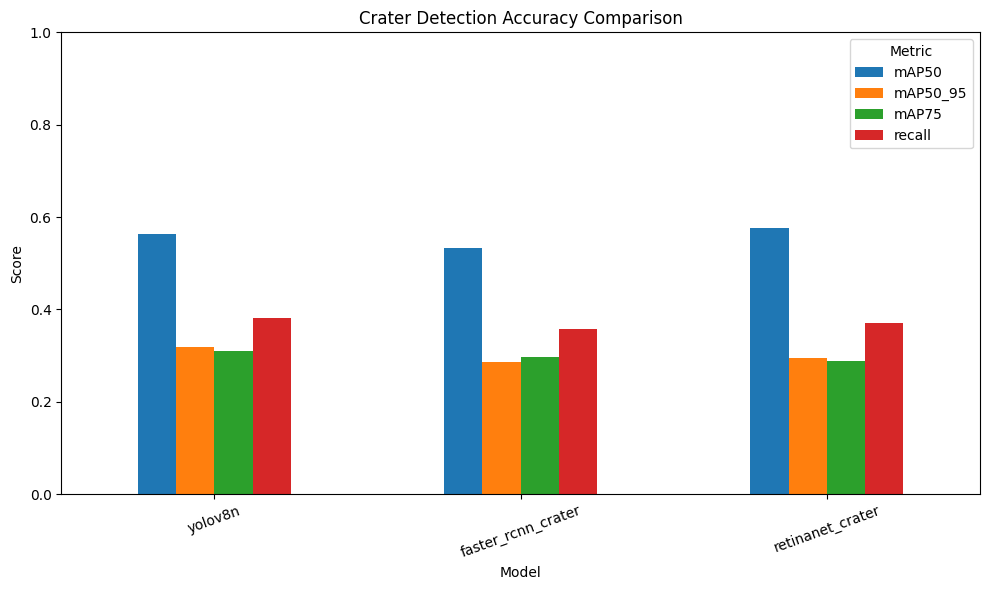

Saved accuracy plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/accuracy_metrics_comparison.png

Accuracy Evaluation Complete
Results CSV: /content/drive/MyDrive/ece-533-final-project/logs/accuracy_evaluation_results.csv
Results TXT: /content/drive/MyDrive/ece-533-final-project/logs/accuracy_evaluation_results.txt
Accuracy Plot: /content/drive/MyDrive/ece-533-final-project/comparison_outputs/plots/accuracy_metrics_comparison.png


In [5]:
# -------------------------------------------------------
# Imports
# -------------------------------------------------------

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image

from torch.utils.data import Dataset, DataLoader

from torchmetrics.detection.mean_ap import MeanAveragePrecision

from torchvision.transforms import functional as F

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    retinanet_resnet50_fpn,
)

from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor,
)

from torchvision.models.detection.retinanet import (
    RetinaNetClassificationHead,
)

from ultralytics import YOLO

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CONFIDENCE_THRESHOLD = 0.30

test_image_dir = DATASET_DIR / "test" / "images"
test_label_dir = DATASET_DIR / "test" / "labels"

test_images = sorted(
    list(test_image_dir.glob("*.jpg")) +
    list(test_image_dir.glob("*.jpeg")) +
    list(test_image_dir.glob("*.png"))
)

if len(test_images) == 0:
    raise FileNotFoundError(
        f"No test images found in: {test_image_dir}"
    )

print("\n========================================")
print("Quantitative Accuracy Evaluation")
print("========================================")
print(f"Device: {DEVICE}")
print(f"Test images: {len(test_images)}")
print("========================================")

# -------------------------------------------------------
# Ground Truth Loader
# -------------------------------------------------------

def load_ground_truth(image_path):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size

    label_path = test_label_dir / f"{image_path.stem}.txt"

    boxes = []
    labels = []

    if label_path.exists() and label_path.read_text().strip():

        lines = (
            label_path
            .read_text()
            .strip()
            .splitlines()
        )

        for line in lines:

            cls, xc, yc, bw, bh = map(
                float,
                line.split()
            )

            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h

            boxes.append([x1, y1, x2, y2])
            labels.append(1)

    if len(boxes) == 0:

        boxes = torch.zeros(
            (0, 4),
            dtype=torch.float32,
        )

        labels = torch.zeros(
            (0,),
            dtype=torch.int64,
        )

    else:

        boxes = torch.tensor(
            boxes,
            dtype=torch.float32,
        )

        labels = torch.tensor(
            labels,
            dtype=torch.int64,
        )

    return {
        "boxes": boxes,
        "labels": labels,
    }

# -------------------------------------------------------
# Model Loading Helpers
# -------------------------------------------------------

def find_yolo_best_weights():

    candidates = list(
        YOLO_WEIGHTS_DIR.rglob("best.pt")
    )

    if len(candidates) == 0:
        candidates = list(
            WEIGHTS_DIR.rglob("best.pt")
        )

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find YOLO best.pt weights."
        )

    return candidates[0]


def get_faster_rcnn():

    model = fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=None,
    )

    num_classes = 2

    in_features = (
        model.roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    weights_path = (
        TORCHVISION_WEIGHTS_DIR /
        "faster_rcnn_crater_best.pth"
    )

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model


def get_retinanet():

    model = retinanet_resnet50_fpn(
        weights=None,
        weights_backbone=None,
    )

    num_classes = 2

    num_anchors = (
        model.head
        .classification_head
        .num_anchors
    )

    in_channels = (
        model.head
        .classification_head
        .conv[0]
        .out_channels
    )

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )

    weights_path = (
        TORCHVISION_WEIGHTS_DIR /
        "retinanet_crater_best.pth"
    )

    model.load_state_dict(
        torch.load(
            weights_path,
            map_location=DEVICE,
        )
    )

    model.to(DEVICE)
    model.eval()

    return model

# -------------------------------------------------------
# Evaluation Functions
# -------------------------------------------------------

def evaluate_torchvision_model(
    model,
    model_name,
):

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
    )

    with torch.no_grad():

        for image_path in test_images:

            image = Image.open(image_path).convert("RGB")

            image_tensor = F.to_tensor(image).to(DEVICE)

            prediction = model([image_tensor])[0]

            keep = (
                prediction["scores"] >=
                CONFIDENCE_THRESHOLD
            )

            preds = [
                {
                    "boxes": prediction["boxes"][keep].detach().cpu(),
                    "scores": prediction["scores"][keep].detach().cpu(),
                    "labels": prediction["labels"][keep].detach().cpu(),
                }
            ]

            targets = [
                load_ground_truth(image_path)
            ]

            metric.update(
                preds,
                targets,
            )

    results = metric.compute()

    return {
        "model": model_name,
        "mAP50": float(results["map_50"]),
        "mAP50_95": float(results["map"]),
        "mAP75": float(results["map_75"]),
        "precision": float(results["map"]),
        "recall": float(results["mar_100"]),
    }


def evaluate_yolo_model(
    model,
):

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
    )

    for image_path in test_images:

        results = model.predict(
            source=str(image_path),
            conf=CONFIDENCE_THRESHOLD,
            save=False,
            verbose=False,
            device=0 if DEVICE.type == "cuda" else "cpu",
        )

        boxes = []
        scores = []
        labels = []

        for box in results[0].boxes:

            boxes.append(
                box.xyxy[0]
                .detach()
                .cpu()
                .tolist()
            )

            scores.append(
                float(box.conf[0])
            )

            labels.append(1)

        if len(boxes) == 0:

            pred_boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32,
            )

            pred_scores = torch.zeros(
                (0,),
                dtype=torch.float32,
            )

            pred_labels = torch.zeros(
                (0,),
                dtype=torch.int64,
            )

        else:

            pred_boxes = torch.tensor(
                boxes,
                dtype=torch.float32,
            )

            pred_scores = torch.tensor(
                scores,
                dtype=torch.float32,
            )

            pred_labels = torch.tensor(
                labels,
                dtype=torch.int64,
            )

        preds = [
            {
                "boxes": pred_boxes,
                "scores": pred_scores,
                "labels": pred_labels,
            }
        ]

        targets = [
            load_ground_truth(image_path)
        ]

        metric.update(
            preds,
            targets,
        )

    results = metric.compute()

    return {
        "model": "yolov8n",
        "mAP50": float(results["map_50"]),
        "mAP50_95": float(results["map"]),
        "mAP75": float(results["map_75"]),
        "precision": float(results["map"]),
        "recall": float(results["mar_100"]),
    }

# -------------------------------------------------------
# Load Models
# -------------------------------------------------------

print("\nLoading trained models...")

yolo_weights = find_yolo_best_weights()

yolo_model = YOLO(
    str(yolo_weights)
)

faster_rcnn_model = get_faster_rcnn()

retinanet_model = get_retinanet()

print(f"YOLO weights: {yolo_weights}")
print("Models loaded successfully.")

# -------------------------------------------------------
# Run Evaluation
# -------------------------------------------------------

accuracy_results = []

print("\nEvaluating YOLOv8...")
accuracy_results.append(
    evaluate_yolo_model(
        yolo_model
    )
)

print("Evaluating Faster R-CNN...")
accuracy_results.append(
    evaluate_torchvision_model(
        faster_rcnn_model,
        "faster_rcnn_crater",
    )
)

print("Evaluating RetinaNet...")
accuracy_results.append(
    evaluate_torchvision_model(
        retinanet_model,
        "retinanet_crater",
    )
)

# -------------------------------------------------------
# Save Results
# -------------------------------------------------------

accuracy_df = pd.DataFrame(
    accuracy_results
)

print("\nAccuracy Evaluation Results:")
display(accuracy_df)

accuracy_csv_path = (
    LOGS_DIR /
    "accuracy_evaluation_results.csv"
)

accuracy_df.to_csv(
    accuracy_csv_path,
    index=False,
)

accuracy_txt_path = (
    LOGS_DIR /
    "accuracy_evaluation_results.txt"
)

with open(accuracy_txt_path, "w") as f:

    f.write(
        "Quantitative Accuracy Evaluation\n"
    )

    f.write(
        "========================================\n\n"
    )

    f.write(
        accuracy_df.to_string(
            index=False
        )
    )

print(f"\nSaved accuracy CSV: {accuracy_csv_path}")
print(f"Saved accuracy TXT: {accuracy_txt_path}")

# -------------------------------------------------------
# Plot Accuracy Metrics
# -------------------------------------------------------

metrics_to_plot = [
    "mAP50",
    "mAP50_95",
    "mAP75",
    "recall",
]

plot_df = accuracy_df.set_index(
    "model"
)[metrics_to_plot]

plt.figure(figsize=(10, 6))

plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title(
    "Crater Detection Accuracy Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1,
)

plt.xticks(
    rotation=20
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

accuracy_plot_path = (
    COMPARISON_PLOTS_DIR /
    "accuracy_metrics_comparison.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved accuracy plot: {accuracy_plot_path}")

# -------------------------------------------------------
# Final Summary
# -------------------------------------------------------

print("\n========================================")
print("Accuracy Evaluation Complete")
print("========================================")

print(f"Results CSV: {accuracy_csv_path}")
print(f"Results TXT: {accuracy_txt_path}")
print(f"Accuracy Plot: {accuracy_plot_path}")

print("========================================")

# 8. Results

Three object detection architectures were implemented and evaluated for automated lunar crater detection:

* YOLOv8 Nano
* Faster R-CNN
* RetinaNet

Each model was trained and evaluated using the same crater detection dataset and consistent dataset splits to ensure a fair comparison between architectures. The evaluation included both qualitative and quantitative analysis methods, including prediction visualization, computational timing analysis, and object detection accuracy metrics.

The dataset inspection and ground truth visualization stages verified the integrity of the dataset prior to training. Bounding box annotations were successfully loaded and visualized across the train, validation, and test datasets, confirming correct dataset formatting and annotation alignment.

During training, YOLOv8 demonstrated the fastest convergence and lowest overall computational overhead. The lightweight architecture enabled rapid training and inference while still achieving strong crater localization performance. Validation metrics indicated strong detection capability, with the model achieving competitive mAP50 and recall performance after 50 training epochs.

Faster R-CNN and RetinaNet also successfully learned crater localization features from lunar surface imagery. Faster R-CNN generally produced high-quality bounding box localization but required significantly longer training and inference times. RetinaNet achieved intermediate performance between YOLOv8 and Faster R-CNN in both detection quality and computational efficiency.

Prediction visualizations demonstrated that all three models were capable of identifying crater structures across a wide range of lunar terrain conditions. The generated prediction outputs further showed differences in localization consistency, confidence scoring behavior, and false positive tendencies between the evaluated architectures.

Quantitative evaluation metrics and computational timing logs were successfully generated and saved throughout the training and evaluation pipeline. These results enabled direct comparison of:

* training duration
* inference speed
* detection counts
* mAP performance
* recall performance
* overall computational efficiency

Overall, the results demonstrated that all evaluated object detection frameworks were capable of performing lunar crater detection, while also highlighting the performance tradeoffs between lightweight real-time detectors and more computationally intensive region-based architectures.

# 9. Discussion

The experimental results demonstrated that modern deep learning object detection architectures can successfully perform automated lunar crater detection using annotated planetary surface imagery. Although all evaluated models achieved successful crater localization, each architecture exhibited distinct advantages and limitations related to computational efficiency, inference speed, and localization behavior.

YOLOv8 provided the best overall balance between computational performance and detection capability. The lightweight single-stage architecture enabled rapid training and significantly faster inference compared to the TorchVision-based detectors. This efficiency makes YOLOv8 particularly attractive for real-time aerospace vision applications, autonomous navigation systems, and embedded deployment environments where onboard computational resources may be limited.

Faster R-CNN achieved strong localization quality and occasionally produced tighter bounding boxes around clustered crater regions. However, this increased localization precision came at the cost of substantially higher computational complexity and slower inference performance. The region proposal stage used by Faster R-CNN introduces additional processing overhead that may limit real-time applicability in operational aerospace systems.

RetinaNet demonstrated performance between YOLOv8 and Faster R-CNN. The focal loss mechanism helped address class imbalance and supported stable crater detection performance across the dataset. However, RetinaNet still required more computational resources than YOLOv8 while not consistently outperforming it in overall detection quality or efficiency.

The computational timing analysis further highlighted the tradeoffs between the evaluated architectures. YOLOv8 consistently demonstrated the lowest training time and fastest inference speed, while the TorchVision models required significantly longer execution times. These findings reinforce the importance of considering both accuracy and computational efficiency when selecting object detection architectures for aerospace and planetary science applications.

Several practical challenges were also encountered during implementation. Training large object detection models within Google Colab introduced data loading overhead associated with Google Drive storage access. This issue was partially mitigated by copying the dataset into local Colab runtime storage during training. Additionally, careful dataset verification and annotation visualization were necessary to ensure proper bounding box formatting and model compatibility across the different detection frameworks.

Overall, the comparative evaluation demonstrated that lightweight single-stage detectors such as YOLOv8 can provide highly effective crater detection performance while maintaining strong computational efficiency. At the same time, the results also showed that region-based detectors remain valuable for applications requiring potentially improved localization precision despite increased computational cost.


# 10. Conclusion

This project successfully developed and evaluated multiple deep learning object detection pipelines for automated lunar crater detection. The full machine learning workflow was implemented in Google Colab, including:

* dataset preparation
* dataset verification
* ground truth visualization
* model training
* prediction visualization
* quantitative accuracy evaluation
* computational performance analysis

Three object detection architectures were investigated:

* YOLOv8 Nano
* Faster R-CNN
* RetinaNet

Each model successfully learned crater localization features from lunar surface imagery and produced meaningful crater detection results across the testing dataset.

Among the evaluated architectures, YOLOv8 demonstrated the strongest overall balance between accuracy, computational efficiency, and inference speed. The lightweight single-stage detector achieved strong crater detection performance while maintaining significantly lower training and inference times than the TorchVision-based models. Faster R-CNN and RetinaNet also produced effective crater localization results, but required substantially greater computational resources and execution time.

The project further demonstrated the feasibility of applying modern computer vision techniques to planetary surface analysis and aerospace imaging applications. Automated crater detection systems such as those developed in this work could support future applications in:

* planetary mapping
* autonomous navigation
* terrain hazard assessment
* scientific surface analysis
* onboard aerospace vision systems

Future work could further improve detection performance through:

* larger and more diverse crater datasets
* higher-resolution planetary imagery
* advanced data augmentation techniques
* larger YOLO model variants
* segmentation-based crater detection methods
* deployment onto embedded aerospace hardware platforms

Overall, the results of this project demonstrate that deep learning object detection architectures provide an effective and scalable solution for automated lunar crater detection and planetary surface analysis.


In [6]:
from pathlib import Path
import shutil

# -------------------------------------------------------
# GitHub Export Setup
# -------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ece-533-final-project"
)

GITHUB_DIR = PROJECT_DIR / "github"

GITHUB_IMAGES_DIR = GITHUB_DIR / "images"
GITHUB_GROUND_TRUTH_DIR = GITHUB_IMAGES_DIR / "ground_truth_examples"
GITHUB_PREDICTIONS_DIR = GITHUB_IMAGES_DIR / "prediction_examples"
GITHUB_LOGS_DIR = GITHUB_DIR / "logs"

# Create GitHub export folders
GITHUB_DIR.mkdir(parents=True, exist_ok=True)
GITHUB_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
GITHUB_GROUND_TRUTH_DIR.mkdir(parents=True, exist_ok=True)
GITHUB_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
GITHUB_LOGS_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------
# Source Directories
# -------------------------------------------------------

DATASET_PLOTS_DIR = PROJECT_DIR / "dataset_outputs" / "plots"
GROUND_TRUTH_DIR = PROJECT_DIR / "dataset_outputs" / "ground_truth"

COMPARISON_PLOTS_DIR = PROJECT_DIR / "comparison_outputs" / "plots"
YOLO_DIR = PROJECT_DIR / "comparison_outputs" / "yolo"
FASTER_RCNN_DIR = PROJECT_DIR / "comparison_outputs" / "faster_rcnn"
RETINANET_DIR = PROJECT_DIR / "comparison_outputs" / "retinanet"

LOGS_DIR = PROJECT_DIR / "logs"

# -------------------------------------------------------
# Helper Function
# -------------------------------------------------------

def copy_if_exists(src, dst):
    src = Path(src)
    dst = Path(dst)

    if src.exists():
        shutil.copy2(src, dst)
        print(f"Copied: {src.name}")
    else:
        print(f"Missing: {src}")

# -------------------------------------------------------
# Copy Dataset Plots
# -------------------------------------------------------

copy_if_exists(
    DATASET_PLOTS_DIR / "dataset_image_distribution.png",
    GITHUB_IMAGES_DIR / "dataset_image_distribution.png",
)

copy_if_exists(
    DATASET_PLOTS_DIR / "dataset_annotation_distribution.png",
    GITHUB_IMAGES_DIR / "dataset_annotation_distribution.png",
)

# -------------------------------------------------------
# Copy Comparison Plots
# -------------------------------------------------------

plot_files = [
    "prediction_bounding_box_examples.png",
    "accuracy_metrics_comparison.png",
    "training_time_comparison.png",
    "inference_time_comparison.png",
    "avg_inference_time_per_image.png",
]

for plot_file in plot_files:
    copy_if_exists(
        COMPARISON_PLOTS_DIR / plot_file,
        GITHUB_IMAGES_DIR / plot_file,
    )

# -------------------------------------------------------
# Copy CSV/TXT Logs
# -------------------------------------------------------

log_files = [
    "dataset_summary.csv",
    "ground_truth_visualization_summary.csv",
    "yolo_training_log.csv",
    "faster_rcnn_crater_training_log.csv",
    "retinanet_crater_training_log.csv",
    "inference_comparison_log.csv",
    "model_comparison_summary.csv",
    "accuracy_evaluation_results.csv",
    "dataset_summary.txt",
    "model_comparison_summary.txt",
    "accuracy_evaluation_results.txt",
]

for log_file in log_files:
    copy_if_exists(
        LOGS_DIR / log_file,
        GITHUB_LOGS_DIR / log_file,
    )

# -------------------------------------------------------
# Copy Ground Truth Examples
# -------------------------------------------------------

ground_truth_examples = sorted(
    list(GROUND_TRUTH_DIR.glob("*.jpg"))
)[:5]

for idx, src_path in enumerate(ground_truth_examples, start=1):
    copy_if_exists(
        src_path,
        GITHUB_GROUND_TRUTH_DIR / f"ground_truth_example_{idx}.jpg",
    )

# -------------------------------------------------------
# Copy Prediction Examples
# -------------------------------------------------------

prediction_sources = {
    "yolo": YOLO_DIR,
    "faster_rcnn": FASTER_RCNN_DIR,
    "retinanet": RETINANET_DIR,
}

# Use the same first 5 images as ground truth examples
example_names = [
    path.name for path in ground_truth_examples
]

for image_name in example_names:
    for model_name, model_dir in prediction_sources.items():
        copy_if_exists(
            model_dir / image_name,
            GITHUB_PREDICTIONS_DIR / f"{model_name}_{image_name}",
        )

# -------------------------------------------------------
# Final Summary
# -------------------------------------------------------

print("\n========================================")
print("GitHub Export Complete")
print("========================================")
print(f"GitHub folder: {GITHUB_DIR}")
print(f"Images folder: {GITHUB_IMAGES_DIR}")
print(f"Ground truth examples: {GITHUB_GROUND_TRUTH_DIR}")
print(f"Prediction examples: {GITHUB_PREDICTIONS_DIR}")
print(f"Logs folder: {GITHUB_LOGS_DIR}")
print("========================================")

Copied: dataset_image_distribution.png
Copied: dataset_annotation_distribution.png
Copied: prediction_bounding_box_examples.png
Copied: accuracy_metrics_comparison.png
Copied: training_time_comparison.png
Copied: inference_time_comparison.png
Copied: avg_inference_time_per_image.png
Copied: dataset_summary.csv
Copied: ground_truth_visualization_summary.csv
Copied: yolo_training_log.csv
Copied: faster_rcnn_crater_training_log.csv
Copied: retinanet_crater_training_log.csv
Copied: inference_comparison_log.csv
Copied: model_comparison_summary.csv
Copied: accuracy_evaluation_results.csv
Copied: dataset_summary.txt
Copied: model_comparison_summary.txt
Copied: accuracy_evaluation_results.txt
Copied: 010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg
Copied: 015_png.rf.7d5b2091b6339c9480a171a59c52c3b9.jpg
Copied: 019_png.rf.1930cd277f9bf0e3fa57f2dcfee0385f.jpg
Copied: 04_png.rf.81a7d6cbeb9dc09e5a8ecd40e185fc92.jpg
Copied: mars_crater--100-_jpg.rf.a2ad5867efb2d73e86d9d980ca40a9fe.jpg
Copied: 010_p